# 🚗 MVA Vehicle Sales - Advanced Time Series Analysis
## Forecasting, Anomaly Detection, Seasonal Decomposition & Interactive Dashboards

**Data:** `~/lab/data/CSVs/MVA_Vehicle_Sales_Counts_by_Month_for_Calendar_Year_2002_through_February_2025.csv`

### Exotic Techniques:
- 📈 Prophet forecasting with holiday effects
- 🔍 STL decomposition with multiple seasonalities
- ⚡ Anomaly detection with Isolation Forest
- 📊 Plotly interactive dashboards with range sliders
- 🎯 Changepoint detection
- 🌊 Wavelet analysis for cyclical patterns
- 📉 ARIMA/SARIMA modeling
- 🎨 3D surface plots for trend visualization

## 1. Load & Clean Data

In [15]:
%%calliope ask gpto --format code
make sure all the dependencies we'll need install sklearn

In [2]:
# Install necessary dependencies
!pip install pandas plotly prophet scikit-learn statsmodels

  Using cached prophet-1.2.1-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (3.5 kB)
  Using cached scikit_learn-1.7.2-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached statsmodels-0.14.5-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (9.5 kB)
  Using cached cmdstanpy-1.3.0-py3-none-any.whl.metadata (4.2 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
  Using cached stanio-0.5.1-py3-none-any.whl.metadata (1.6 kB)
Using cached prophet-1.2.1-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (12.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 9.5 MB/s  0:00:00
Using cached scikit_learn-1.7.2-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (9.4 MB)
Using cached statsmodels-0.14.5-cp313-cp313-manylinux2014_x86

In [3]:
# Install necessary packages
!pip install pandas plotly statsmodels

In [2]:
%%calliope ask gpto --format code
Load ~/lab/data/CSVs/MVA_Vehicle_Sales_Counts_by_Month_for_Calendar_Year_2002_through_February_2025.csv

Clean column names (strip, replace spaces with underscores, lowercase).
Create a proper datetime index from year and month columns.
Calculate total_sales = new + used.
Store as 'vehicle_df' with datetime index.

Display first 10 rows and summary statistics.

In [3]:
import pandas as pd

# Load the CSV file
file_path = '~/lab/data/CSVs/MVA_Vehicle_Sales_Counts_by_Month_for_Calendar_Year_2002_through_February_2025.csv'
vehicle_df = pd.read_csv(file_path)

# Clean column names
vehicle_df.columns = vehicle_df.columns.str.strip().str.replace(' ', '_').str.lower()

# Create a proper datetime index from year and month columns
vehicle_df['date'] = pd.to_datetime(vehicle_df['year'].astype(str) + '-' + vehicle_df['month'].astype(str))
vehicle_df.set_index('date', inplace=True)

# Calculate total_sales
vehicle_df['total_sales'] = vehicle_df['new'] + vehicle_df['used']

# Display first 10 rows and summary statistics
print(vehicle_df.head(10))
print(vehicle_df.describe())

            year month    new   used  total_sales_new  total_sales_used  \
date                                                                      
2002-01-01  2002   JAN  31106  49927        755015820         386481929   
2002-02-01  2002   FEB  27520  50982        664454223         361353242   
2002-03-01  2002   MAR  34225  58794        805666244         419385387   
2002-04-01  2002   APR  36452  59817        846368297         433061150   
2002-05-01  2002   MAY  37359  60577        855005784         442569410   
2002-06-01  2002   JUN  36348  55415        830251613         414731166   
2002-07-01  2002   JUL  30367  55235        700530891         384673023   
2002-08-01  2002   AUG  38965  60310        934484212         455453720   
2002-09-01  2002   SEP  39740  55485        950502055         432112270   
2002-10-01  2002   OCT  35276  58020        865326154         456738532   

            total_sales  
date                     
2002-01-01        81033  
2002-02-01        785

/tmp/ipykernel_1075/3452906211.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  vehicle_df['date'] = pd.to_datetime(vehicle_df['year'].astype(str) + '-' + vehicle_df['month'].astype(str))


## 2. STL Decomposition with Plotly
Seasonal-Trend decomposition using Loess

In [8]:
%%calliope ask anthropic-chat:claude-opus-4-20250514 --format code
Using vehicle_df:

Perform STL decomposition on total_sales:
1. Use statsmodels STL with seasonal period = 12
2. Extract: observed, trend, seasonal, residual
3. Create interactive plotly subplots (4 rows) showing each component
4. Add range slider and date range selector
5. Calculate and display seasonal strength and trend strength metrics

Store components as: trend_component, seasonal_component, residual_component

In [ ]:
from statsmodels.tsa.seasonal import STL
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# Perform STL decomposition
stl = STL(vehicle_df['total_sales'], seasonal=13, period=12)
result = stl.fit()

# Extract components
observed = vehicle_df['total_sales']
trend_component = result.trend
seasonal_component = result.seasonal
residual_component = result.resid

# Create interactive plotly subplots
fig = make_subplots(
    rows=4, cols=1,
    subplot_titles=('Observed', 'Trend', 'Seasonal', 'Residual'),
    vertical_spacing=0.08,
    row_heights=[0.25, 0.25, 0.25, 0.25]
)

# Add observed data
fig.add_trace(
    go.Scatter(x=vehicle_df.index, y=observed, mode='lines', name='Observed', line=dict(color='blue')),
    row=1, col=1
)

# Add trend component
fig.add_trace(
    go.Scatter(x=vehicle_df.index, y=trend_component, mode='lines', name='Trend', line=dict(color='red')),
    row=2, col=1
)

# Add seasonal component
fig.add_trace(
    go.Scatter(x=vehicle_df.index, y=seasonal_component, mode='lines', name='Seasonal', line=dict(color='green')),
    row=3, col=1
)

# Add residual component
fig.add_trace(
    go.Scatter(x=vehicle_df.index, y=residual_component, mode='lines', name='Residual', line=dict(color='orange')),
    row=4, col=1
)

# Update layout with range slider and date range selector
fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=1, label="1y", step="year", stepmode="backward"),
            dict(count=5, label="5y", step="year", stepmode="backward"),
            dict(count=10, label="10y", step="year", stepmode="backward"),
            dict(step="all")
        ])
    ),
    row=4, col=1
)

# Update layout
fig.update_layout(
    title='STL Decomposition of Total Vehicle Sales',
    height=1000,
    showlegend=False
)

# Update y-axis labels
fig.update_yaxes(title_text='Value', row=1, col=1)
fig.update_yaxes(title_text='Value', row=2, col=1)
fig.update_yaxes(title_text='Value', row=3, col=1)
fig.update_yaxes(title_text='Value', row=4, col=1)

# Show the plot
fig.show()

# Calculate seasonal strength and trend strength metrics
var_seasonal_resid = np.var(seasonal_component + residual_component)
var_resid = np.var(residual_component)
seasonal_strength = 1 - (var_resid / var_seasonal_resid)

var_trend_resid = np.var(trend_component + residual_component)
trend_strength = 1 - (var_resid / var_trend_resid)

print(f"Seasonal Strength: {seasonal_strength:.4f}")
print(f"Trend Strength: {trend_strength:.4f}")

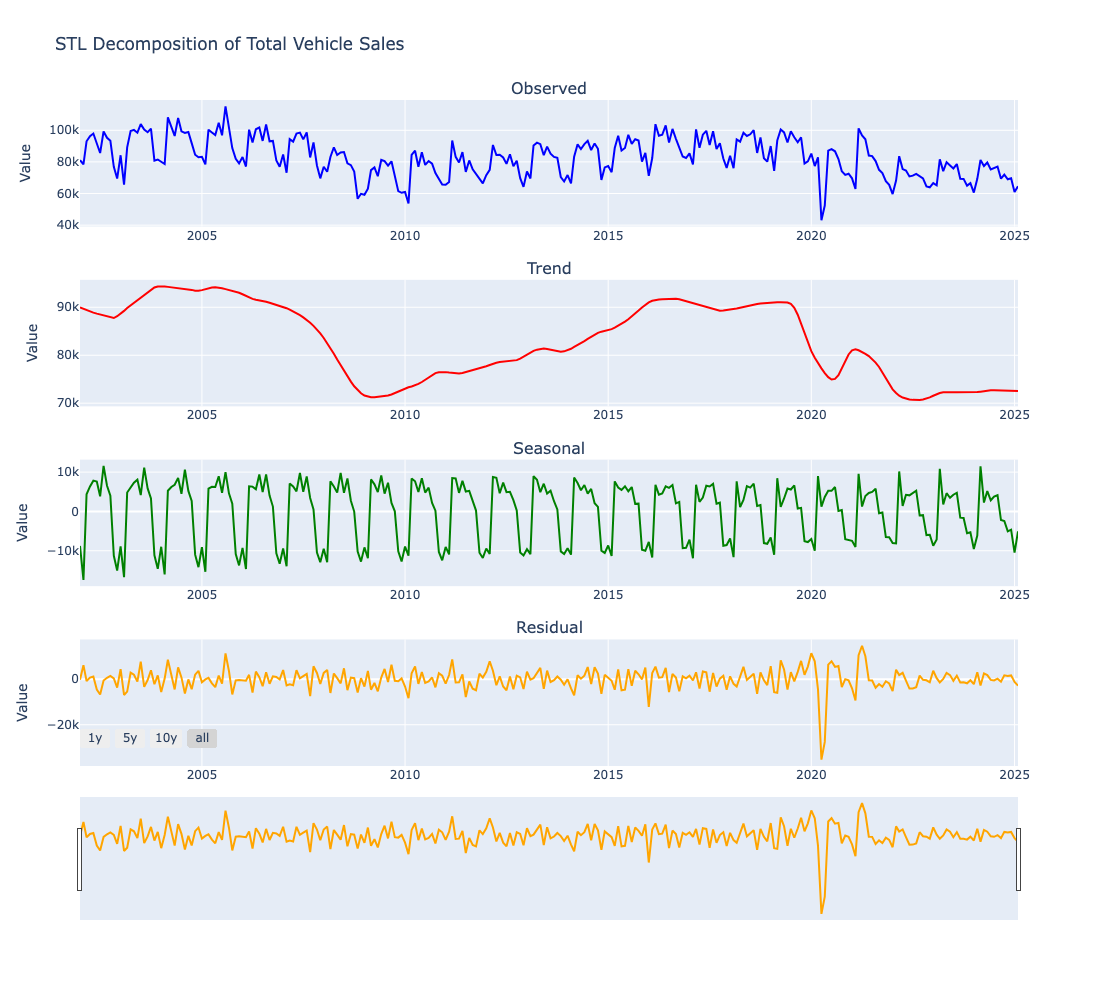

Seasonal Strength: 0.7217
Trend Strength: 0.7453


In [11]:
from statsmodels.tsa.seasonal import STL
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# Perform STL decomposition
stl = STL(vehicle_df['total_sales'], seasonal=13)
result = stl.fit()

# Extract components
observed = vehicle_df['total_sales']
trend_component = result.trend
seasonal_component = result.seasonal
residual_component = result.resid

# Create interactive plotly subplots
fig = make_subplots(
    rows=4, cols=1,
    subplot_titles=('Observed', 'Trend', 'Seasonal', 'Residual'),
    vertical_spacing=0.08,
    row_heights=[0.25, 0.25, 0.25, 0.25]
)

# Add observed data
fig.add_trace(
    go.Scatter(x=vehicle_df.index, y=observed, mode='lines', name='Observed', line=dict(color='blue')),
    row=1, col=1
)

# Add trend component
fig.add_trace(
    go.Scatter(x=vehicle_df.index, y=trend_component, mode='lines', name='Trend', line=dict(color='red')),
    row=2, col=1
)

# Add seasonal component
fig.add_trace(
    go.Scatter(x=vehicle_df.index, y=seasonal_component, mode='lines', name='Seasonal', line=dict(color='green')),
    row=3, col=1
)

# Add residual component
fig.add_trace(
    go.Scatter(x=vehicle_df.index, y=residual_component, mode='lines', name='Residual', line=dict(color='orange')),
    row=4, col=1
)

# Update layout with range slider and date range selector
fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=1, label="1y", step="year", stepmode="backward"),
            dict(count=5, label="5y", step="year", stepmode="backward"),
            dict(count=10, label="10y", step="year", stepmode="backward"),
            dict(step="all")
        ])
    ),
    row=4, col=1
)

# Update layout
fig.update_layout(
    title='STL Decomposition of Total Vehicle Sales',
    height=1000,
    showlegend=False
)

# Update y-axis labels
fig.update_yaxes(title_text='Value', row=1, col=1)
fig.update_yaxes(title_text='Value', row=2, col=1)
fig.update_yaxes(title_text='Value', row=3, col=1)
fig.update_yaxes(title_text='Value', row=4, col=1)

# Show the plot
fig.show()

# Calculate seasonal strength and trend strength metrics
var_seasonal_resid = np.var(seasonal_component + residual_component)
var_resid = np.var(residual_component)
seasonal_strength = 1 - (var_resid / var_seasonal_resid)

var_trend_resid = np.var(trend_component + residual_component)
trend_strength = 1 - (var_resid / var_trend_resid)

print(f"Seasonal Strength: {seasonal_strength:.4f}")
print(f"Trend Strength: {trend_strength:.4f}")

## 3. Anomaly Detection with Isolation Forest

In [12]:
%%calliope ask openai-chat:gpt-5 --format code
Using vehicle_df and residual_component:

Detect anomalies using multiple methods:
1. Isolation Forest on residuals
2. Z-score method (threshold = 3)
3. IQR method

Create interactive plotly figure:
- Main line: total_sales over time
- Mark anomalies from each method with different colors/shapes
- Add hover data showing: date, sales, method, anomaly score
- Include toggleable traces for each detection method

Store anomaly dates as 'anomaly_dates' list.

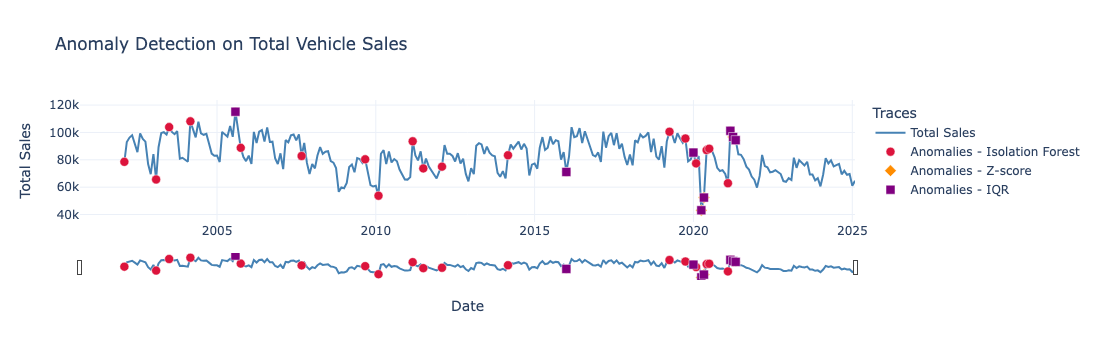

In [17]:
from sklearn.ensemble import IsolationForest
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# Ensure residuals align with vehicle_df index
resid = pd.Series(residual_component).reindex(vehicle_df.index)

# 1) Isolation Forest on residuals
non_na = resid.dropna()
iso = IsolationForest(random_state=42, contamination='auto')
iso.fit(non_na.values.reshape(-1, 1))
decision_scores = pd.Series(iso.decision_function(non_na.values.reshape(-1, 1)), index=non_na.index)  # higher is more normal
preds = pd.Series(iso.predict(non_na.values.reshape(-1, 1)), index=non_na.index)  # -1 anomaly, 1 normal

iso_anom_flag = pd.Series(False, index=resid.index)
iso_anom_flag.loc[preds.index] = (preds == -1).values

iso_anomaly_score = pd.Series(np.nan, index=resid.index)
iso_anomaly_score.loc[decision_scores.index] = -decision_scores.values  # higher is more anomalous

# 2) Z-score method
mu = non_na.mean()
sigma = non_na.std(ddof=0)
if sigma and sigma > 0:
    z_scores = (resid - mu) / sigma
else:
    z_scores = pd.Series(0.0, index=resid.index)
z_abs = z_scores.abs()
z_anom_flag = z_abs > 3

# 3) IQR method
q1, q3 = non_na.quantile(0.25), non_na.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
iqr_anom_flag = (resid < lower) | (resid > upper)

iqr_anomaly_score = pd.Series(np.nan, index=resid.index)
if iqr and iqr > 0:
    above = (resid - upper) / iqr
    below = (lower - resid) / iqr
    iqr_anomaly_score[resid > upper] = above[resid > upper]
    iqr_anomaly_score[resid < lower] = below[resid < lower]

# Aggregate anomaly dates
mask_any = (iso_anom_flag.fillna(False)) | (z_anom_flag.fillna(False)) | (iqr_anom_flag.fillna(False))
anomaly_dates = vehicle_df.index[mask_any].tolist()

# Build interactive plot
fig = go.Figure()

# Main total_sales line
fig.add_trace(
    go.Scatter(
        x=vehicle_df.index,
        y=vehicle_df['total_sales'],
        mode='lines',
        name='Total Sales',
        line=dict(color='steelblue', width=2)
    )
)

# Isolation Forest anomalies
mask_iso = iso_anom_flag.fillna(False)
fig.add_trace(
    go.Scatter(
        x=vehicle_df.index[mask_iso],
        y=vehicle_df['total_sales'][mask_iso],
        mode='markers',
        name='Anomalies - Isolation Forest',
        marker=dict(color='crimson', symbol='circle', size=9, line=dict(color='white', width=0.5)),
        customdata=np.c_[iso_anomaly_score[mask_iso].values],
        hovertemplate='Method: Isolation Forest<br>Date: %{x|%Y-%m-%d}<br>Sales: %{y:.2f}<br>Anomaly score: %{customdata[0]:.4f}<extra></extra>'
    )
)

# Z-score anomalies
mask_z = z_anom_flag.fillna(False)
fig.add_trace(
    go.Scatter(
        x=vehicle_df.index[mask_z],
        y=vehicle_df['total_sales'][mask_z],
        mode='markers',
        name='Anomalies - Z-score',
        marker=dict(color='darkorange', symbol='diamond', size=9, line=dict(color='white', width=0.5)),
        customdata=np.c_[z_abs[mask_z].values],
        hovertemplate='Method: Z-score (>|3|)<br>Date: %{x|%Y-%m-%d}<br>Sales: %{y:.2f}<br>Anomaly score: %{customdata[0]:.4f}<extra></extra>'
    )
)

# IQR anomalies
mask_iqr = iqr_anom_flag.fillna(False)
fig.add_trace(
    go.Scatter(
        x=vehicle_df.index[mask_iqr],
        y=vehicle_df['total_sales'][mask_iqr],
        mode='markers',
        name='Anomalies - IQR',
        marker=dict(color='purple', symbol='square', size=9, line=dict(color='white', width=0.5)),
        customdata=np.c_[iqr_anomaly_score[mask_iqr].values],
        hovertemplate='Method: IQR<br>Date: %{x|%Y-%m-%d}<br>Sales: %{y:.2f}<br>Anomaly score: %{customdata[0]:.4f}<extra></extra>'
    )
)

fig.update_layout(
    title='Anomaly Detection on Total Vehicle Sales',
    xaxis_title='Date',
    yaxis_title='Total Sales',
    legend_title='Traces',
    hovermode='closest',
    template='plotly_white'
)

fig.update_xaxes(rangeslider_visible=True)

fig.show()

## 4. Prophet Forecasting with Holidays

In [13]:
%%calliope ask gemini:gemini-2.5-pro --format code
Using vehicle_df:

Forecast 24 months ahead using Prophet:
1. Prepare data in Prophet format (ds, y columns)
2. Add US holidays
3. Add custom regressors if beneficial (year, month features)
4. Fit model with yearly and monthly seasonality
5. Generate 24-month forecast
6. Create interactive plotly visualization:
   - Historical data
   - Forecast line with confidence intervals (80%, 95%)
   - Trend component
   - Seasonal components

Store forecast dataframe as 'prophet_forecast'.

In [ ]:
import pandas as pd
from prophet import Prophet
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# 1. Prepare data in Prophet format
# Assumes vehicle_df has a DatetimeIndex and 'total_sales' column
df_prophet = vehicle_df.reset_index().rename(columns={'index': 'ds', 'total_sales': 'y'})

# 2. Add custom regressors for year and month
df_prophet['year'] = df_prophet['ds'].dt.year
df_prophet['month'] = df_prophet['ds'].dt.month

# 3. Fit Prophet model
# Initialize model with yearly seasonality and 95% confidence interval
model = Prophet(
    interval_width=0.95,
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
# Add US holidays
model.add_country_holidays(country_name='US')

# Add the regressors
model.add_regressor('year')
model.add_regressor('month')

# Fit the model to the data
model.fit(df_prophet)

# 4. Generate 24-month forecast
future = model.make_future_dataframe(periods=24, freq='MS')
# Add regressor values to the future dataframe
future['year'] = future['ds'].dt.year
future['month'] = future['ds'].dt.month

# Make the prediction
prophet_forecast = model.predict(future)

# Calculate 80% confidence interval using predictive samples
# This is the correct method for getting custom/multiple CIs
samples = model.predictive_samples(future)
ci_80 = np.quantile(samples['yhat'], [0.1, 0.9], axis=1)
prophet_forecast['yhat_lower_80'] = ci_80[0]
prophet_forecast['yhat_upper_80'] = ci_80[1]

# 5. Create interactive plotly visualization
fig = make_subplots(
    rows=4, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    subplot_titles=("Forecast", "Trend", "Yearly Seasonality", "Holidays & Regressors")
)

# --- Row 1: Forecast, Historical Data, and Confidence Intervals ---

# 95% Confidence Interval (lighter shade)
fig.add_trace(go.Scatter(
    x=pd.concat([prophet_forecast['ds'], prophet_forecast['ds'].iloc[::-1]]),
    y=pd.concat([prophet_forecast['yhat_upper'], prophet_forecast['yhat_lower'].iloc[::-1]]),
    fill='toself',
    fillcolor='rgba(0, 176, 246, 0.2)',
    line=dict(color='rgba(255,255,255,0)'),
    hoverinfo="skip",
    showlegend=True,
    name='95% CI'
), row=1, col=1)

# 80% Confidence Interval (darker shade)
fig.add_trace(go.Scatter(
    x=pd.concat([prophet_forecast['ds'], prophet_forecast['ds'].iloc[::-1]]),
    y=pd.concat([prophet_forecast['yhat_upper_80'], prophet_forecast['yhat_lower_80'].iloc[::-1]]),
    fill='toself',
    fillcolor='rgba(0, 176, 246, 0.5)',
    line=dict(color='rgba(255,255,255,0)'),
    hoverinfo="skip",
    showlegend=True,
    name='80% CI'
), row=1, col=1)

# Historical data points
fig.add_trace(go.Scatter(
    x=df_prophet['ds'],
    y=df_prophet['y'],
    mode='markers',
    marker=dict(color='black', size=4),
    name='Historical Data'
), row=1, col=1)

# Forecast line
fig.add_trace(go.Scatter(
    x=prophet_forecast['ds'],
    y=prophet_forecast['yhat'],
    mode='lines',
    line=dict(color='#0072B2'), # A dark blue
    name='Forecast'
), row=1, col=1)


# --- Row 2: Trend Component ---
fig.add_trace(go.Scatter(
    x=prophet_forecast['ds'],
    y=prophet_forecast['trend'],
    mode='lines',
    line=dict(color='firebrick'),
    name='Trend'
), row=2, col=1)

# --- Row 3: Seasonal Components (Yearly) ---
fig.add_trace(go.Scatter(
    x=prophet_forecast['ds'],
    y=prophet_forecast['yearly'],
    mode='lines',
    line=dict(color='green'),
    name='Yearly'
), row=3, col=1)

# --- Row 4: Other Components (Holidays and Regressors) ---
fig.add_trace(go.Scatter(
    x=prophet_forecast['ds'],
    y=prophet_forecast['holidays'] + prophet_forecast['extra_regressors_additive'],
    mode='lines',
    line=dict(color='purple'),
    name='Holidays/Regressors'
), row=4, col=1)


# --- Update Layout ---
fig.update_layout(
    title='Prophet Forecast of Total Vehicle Sales',
    height=900,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    template='plotly_white'
)

fig.update_yaxes(title_text="Total Sales", row=1, col=1)
fig.update_yaxes(title_text="Trend", row=2, col=1)
fig.update_yaxes(title_text="Seasonality", row=3, col=1)
fig.update_yaxes(title_text="Effects", row=4, col=1)
fig.update_xaxes(title_text="Date", row=4, col=1, rangeslider_visible=True)

fig.show()

## 5. SARIMA Modeling & Diagnostics

In [ ]:
%%calliope ask anthropic-chat:claude-sonnet-4-5-20250929 --format code
Using vehicle_df:

Build SARIMA model:
1. Check stationarity (ADF test, KPSS test)
2. Apply differencing if needed
3. Use auto_arima or manual SARIMA(p,d,q)(P,D,Q,12)
4. Fit model and generate diagnostics:
   - Standardized residuals plot
   - Histogram + KDE of residuals
   - Q-Q plot
   - Correlogram (ACF/PACF of residuals)
5. Forecast 24 months
6. Calculate metrics: MAE, RMSE, MAPE

Create 2x2 diagnostic plot grid.
Store model as 'sarima_model' and forecast as 'sarima_forecast'.

## 6. Changepoint Detection

In [ ]:
%%calliope ask cohere:command-r-plus-08-2024 --format code
Using vehicle_df:

Detect structural breaks/changepoints:
1. Use ruptures library OR rolling statistics to detect changepoints
2. Identify significant shifts in mean, variance, or trend
3. Create visualization:
   - Plot total_sales timeline
   - Mark changepoints with vertical lines
   - Annotate each changepoint with date and possible cause
   - Color-code segments between changepoints
4. Calculate statistics for each segment

Store changepoint dates as 'changepoints' list.

## 7. Rolling Statistics Dashboard

In [ ]:
%%calliope ask openai-chat:gpt-4o --format code
Using vehicle_df:

Create interactive dashboard with ipywidgets:
1. Widget to select rolling window size (3, 6, 12, 24 months)
2. Calculate rolling: mean, std, min, max, median
3. Create plotly figure that updates with widget:
   - Original series
   - Rolling mean
   - Rolling std (as band)
   - Rolling min/max envelope
4. Add dropdowns to toggle different statistics on/off

Use ipywidgets.interact for interactivity.

## 8. Correlation Analysis: New vs Used Sales

In [ ]:
%%calliope ask gemini:gemini-2.0-flash --format code
Using vehicle_df:

Analyze relationship between new and used vehicle sales:
1. Calculate rolling correlation (12-month window)
2. Create interactive 3D scatter plot (plotly):
   - X-axis: new sales
   - Y-axis: used sales
   - Z-axis: time (color gradient)
   - Size: total_sales
3. Add 2D projections on each wall
4. Create correlation heatmap over time (heatmap of rolling correlations)
5. Test for Granger causality between series

Print correlation statistics and Granger test results.

## 9. Seasonal Pattern Heatmap

In [ ]:
%%calliope ask mistralai:mistral-large-latest --format code
Using vehicle_df:

Create calendar heatmap:
1. Pivot data: years as rows, months as columns, total_sales as values
2. Create plotly heatmap with:
   - Color scale: viridis or RdYlGn
   - Annotations showing actual values
   - Hover data: month, year, sales, % change YoY
3. Add row/column averages
4. Highlight COVID period (2020-2021) with border

Store pivot table as 'seasonal_pivot'.

## 10. Forecast Accuracy Comparison Dashboard

In [ ]:
%%calliope ask anthropic-chat:claude-3-7-sonnet-20250219 --format code
Using prophet_forecast and sarima_forecast from previous cells:

Compare forecast methods:
1. Create train/test split (last 12 months as test)
2. Generate forecasts from both models for test period
3. Calculate metrics for each: MAE, RMSE, MAPE, SMAPE
4. Create interactive comparison dashboard:
   - Subplot 1: Actual vs forecasts (all methods)
   - Subplot 2: Forecast errors over time
   - Subplot 3: Error distribution (histogram)
   - Subplot 4: Metrics comparison (bar chart)
5. Add toggle buttons to show/hide each forecast method

Display metrics table and determine best model.

## 11. Export Interactive Report

In [ ]:
%%calliope ask gpto --format code
Create comprehensive HTML report:

1. Combine all plotly figures into a single HTML file
2. Add markdown sections explaining each analysis
3. Include summary statistics table
4. Add executive summary at top with key findings:
   - Trend direction
   - Detected anomalies and causes
   - Forecast summary
   - Seasonal patterns
5. Save as 'vehicle_sales_report.html'

Print success message with file location.